In [1]:
import torch
from torch.utils.data import Dataset
import rasterio
import numpy as np
import glob
import matplotlib.pyplot as plt

class FeatureCubeDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file = self.file_paths[idx]
        with rasterio.open(file) as src:
            arr = src.read()  # shape: (C, H, W)
        
        # last channel is the label
        image = arr[:-1].astype(np.float32)  # (C-1, H, W)
        mask = arr[-1].astype(np.int64)      # (H, W)
        
        # Sanitize image
        image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
        
        if self.transform:
            # You can add augmentations if needed
            augmented = self.transform(image=image.transpose(1,2,0), mask=mask)
            image = augmented["image"].transpose(2,0,1)
            mask = augmented["mask"]
        
        return torch.tensor(image), torch.tensor(mask)


In [2]:
from torch.utils.data import DataLoader, random_split

all_files = glob.glob("data/feature_cubes/*.tif")
train_size = int(0.8 * len(all_files))
val_size = len(all_files) - train_size

train_files, val_files = random_split(all_files, [train_size, val_size])

train_dataset = FeatureCubeDataset(train_files)
val_dataset   = FeatureCubeDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)


In [3]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",        # backbone
    encoder_weights="imagenet",     # use pretrained
    in_channels=8,                  # number of feature channels
    classes=2,                      # good/bad
)


In [4]:
import torch

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [5]:
from tqdm import tqdm
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

num_epochs = 28
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    # Training loop with progress bar
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for images, masks in train_bar:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)  # (B, 2, H, W)
        
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())  # live update of current loss

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}")

    # Validation loop with progress bar
    model.eval()
    val_loss = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Val Loss: {avg_val_loss:.4f}")


Epoch 1, Train Loss: 0.4518


Epoch 1, Val Loss: 0.3825


Epoch 2, Train Loss: 0.3654


Epoch 2, Val Loss: 0.3984


Epoch 3, Train Loss: 0.3280


...

Epoch 26, Val Loss: 0.0801


Epoch 27, Train Loss: 0.0537


Epoch 27, Val Loss: 0.1029


Epoch 28, Train Loss: 0.0566


Epoch 28, Val Loss: 0.0784


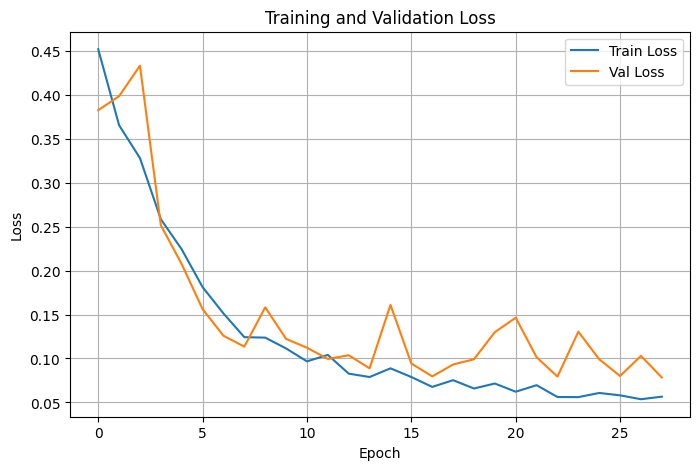

In [6]:
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(train_losses, val_losses)

In [7]:

def evaluate_model(model, data_loader, device="cuda"):
    model.eval()
    total_pixels = 0
    correct_pixels = 0
    iou_scores = []
    dice_scores = []

    with torch.no_grad():
        for images, masks in tqdm(data_loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)  # (B, C, H, W)
            preds = torch.argmax(outputs, dim=1)  # (B, H, W)

            # Flatten for easier computation
            preds_flat = preds.view(-1).cpu().numpy()
            masks_flat = masks.view(-1).cpu().numpy()

            # Accuracy
            correct_pixels += np.sum(preds_flat == masks_flat)
            total_pixels += len(masks_flat)

            # Compute IoU and Dice for each batch
            intersection = np.logical_and(preds_flat == 1, masks_flat == 1).sum()
            union = np.logical_or(preds_flat == 1, masks_flat == 1).sum()
            if union > 0:
                iou = intersection / union
                iou_scores.append(iou)

            dice = (2 * intersection) / (np.sum(preds_flat == 1) + np.sum(masks_flat == 1) + 1e-7)
            dice_scores.append(dice)

    pixel_accuracy = correct_pixels / total_pixels
    mean_iou = np.mean(iou_scores)
    mean_dice = np.mean(dice_scores)

    print(f"Pixel Accuracy: {pixel_accuracy:.4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"Mean Dice: {mean_dice:.4f}")

    return pixel_accuracy, mean_iou, mean_dice

pixel_accuracies, mean_ious, mean_dices = evaluate_model(model, val_loader, device=device)


Evaluating: 100%|██████████| 101/101 [00:02<00:00, 37.36it/s]

Pixel Accuracy: 0.9793
Mean IoU: 0.9468
Mean Dice: 0.9700
